In [1]:
#inspired by
#https://aliyasineser.medium.com/opencv-camera-calibration-e9a48bdd1844

# Mount drive
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [2]:
cd /content/drive/MyDrive/calibration/Post_Processing_B/

/content/drive/MyDrive/calibration/Post_Processing_B


In [5]:
import sys
print(sys.version)
print(sys.path)

3.7.11 (default, Jul  3 2021, 18:01:19) 
[GCC 7.5.0]
['', '/content', '/env/python', '/usr/lib/python37.zip', '/usr/lib/python3.7', '/usr/lib/python3.7/lib-dynload', '/usr/local/lib/python3.7/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.7/dist-packages/IPython/extensions', '/root/.ipython']


In [1]:
import numpy as np
import cv2
import glob
%matplotlib inline
#The line above is necesary to show Matplotlib's plots inside a Jupyter Notebook
from matplotlib import pyplot as plt

In [2]:
cv2.__version__

'4.5.1'

In [3]:
dirpath = '/calibration_chess/'

In [4]:
prefix = '3agosto'
image_format = 'jpg'
square_size = 0.025
width=9
height=6
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)


In [10]:
images = glob.glob('./calibration_chess/*.jpg')

In [12]:
img = cv2.imread(images[0])


In [15]:
#plt.imshow(img)

In [16]:

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

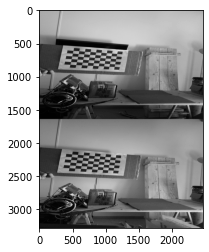

In [19]:
plt.imshow(gray , cmap='gray')

In [20]:
ret, corners = cv2.findChessboardCorners(gray, (width, height), cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)

In [23]:
#corners

In [24]:
corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
img = cv2.drawChessboardCorners(img, (width, height), corners2, ret)


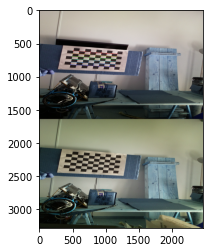

In [25]:
plt.imshow(img , cmap = 'gray')

In [29]:
objp.shape

(54, 3)

In [5]:
# termination criteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

def calibrate(dirpath, prefix, image_format, square_size, width=9, height=6):
    """ Apply camera calibration operation for images in the given directory path. """
    # prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(8,6,0)
    objp = np.zeros((height*width, 3), np.float32)
    objp[:, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)
    objp = objp * square_size
    
    # Arrays to store object points and image points from all the images.
    objpoints = []  # 3d point in real world space
    imgpoints = []  # 2d points in image plane.
    # Some people will add "/" character to the end. It may brake the code so I wrote a check.
    if dirpath[-1:] == '/':
        dirpath = dirpath[:-1]
    images = glob.glob(dirpath+'/' + prefix + '*.' + image_format) #
    
    for fname in images:
        img = cv2.imread(fname)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Find the chess board corners
        #ret, corners = cv2.findChessboardCorners(gray, (width, height), None)
        ret, corners = cv2.findChessboardCorners(gray, (width, height), cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)

        # If found, add object points, image points (after refining them)
        if ret:
            objpoints.append(objp)

            corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
            imgpoints.append(corners2)

            # Draw and display the corners
            img = cv2.drawChessboardCorners(img, (width, height), corners2, ret)
            #cv2.imshow('img',img)
            #cv2.waitKey(500)

    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

    return [ret, mtx, dist, rvecs, tvecs, objpoints, imgpoints]

In [6]:
ret, mtx, dist, rvecs, tvecs, objpoints, imgpointsL = calibrate(dirpath, prefix, image_format, square_size, width=9, height=6)

In [7]:
#printing camera and distortion matrix
mtx, dist

(array([[1.46806492e+03, 0.00000000e+00, 7.28012689e+02],
        [0.00000000e+00, 2.59432534e+03, 1.08837244e+03],
        [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]]),
 array([[-0.03068861,  1.16800829, -0.0332149 , -0.02799338, -2.674353  ]]))

In [8]:
import pickle
def save_coefficients(mtx, dist, pathMatrix, pathDist):
    """ Save the camera matrix and the distortion coefficients to given path/file. """
    afile = open(r''+pathMatrix, 'wb')
    pickle.dump(mtx, afile)
    afile.close()
    afile = open(r''+pathDist, 'wb')
    pickle.dump(dist, afile)
    afile.close()
def load_coefficients(pathMatrix,pathDist):
    """ Loads camera matrix and distortion coefficients. """
    file2 = open(r''+pathMatrix, 'rb')
    mtx = pickle.load(file2)
    file2.close()
    file2 = open(r''+pathDist, 'rb')
    dist = pickle.load(file2)
    file2.close()
    
    return [mtx, dist]

In [9]:
save_coefficients(mtx,dist,'/content/drive/MyDrive/calibration/separation_u/mtx_up.pkl','/content/drive/MyDrive/calibration/separation_u/dist_up.pkl')

In [10]:
mtx,dist = load_coefficients('/content/drive/MyDrive/calibration/separation_u/mtx_up.pkl','/content/drive/MyDrive/calibration/separation_u/dist_up.pkl')

In [11]:
mtx

array([[1.46806492e+03, 0.00000000e+00, 7.28012689e+02],
       [0.00000000e+00, 2.59432534e+03, 1.08837244e+03],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

# TEST Distortion Matrix - Upper lens



True

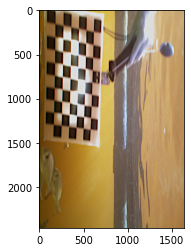

In [13]:
from matplotlib import pyplot as plt
img = cv2.imread('/content/drive/MyDrive/calibration/separation_u/3agosto_ppB_1628005329_u.jpg')
h,  w = img.shape[:2]
newcameramtx_u, roi=cv2.getOptimalNewCameraMatrix(mtx,dist,(w,h),1,(w,h))
plt.imshow(img)
cv2.imwrite('1628005702photo_u_calibrated.jpg', img)

(41, 79, 1075, 1911)


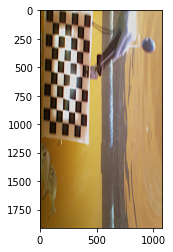

In [14]:
 # undistort
dst = cv2.undistort(img, mtx, dist, None, newcameramtx_u)
# crop the image
x,y,w,h = roi
print(roi)
dst = dst[y:y+h, x:x+w]
plt.imshow(dst)

# Camera lower lens - camera and distrotion matrix

In [15]:
dirpath = '/content/drive/MyDrive/calibration/separation_d'

In [16]:
ret, mtx_d, dist_d, rvecs, tvecs, objpoints, imgpointsR = calibrate(dirpath, prefix, image_format, square_size, width=9, height=6)

In [17]:
mtx_d, dist_d

(array([[1.68826023e+03, 0.00000000e+00, 8.03476021e+02],
        [0.00000000e+00, 2.95031610e+03, 1.15659968e+03],
        [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]]),
 array([[ 1.19224541e-01,  1.88754748e+00, -3.24001493e-03,
         -2.42273459e-03, -7.86586046e+00]]))

In [18]:
save_coefficients(mtx_d,dist_d,'/content/drive/MyDrive/calibration/separation_d/mtx_down.pkl','/content/drive/MyDrive/calibration/separation_d/dist_down.pkl')

# Test Distortion Matrix - lower lens

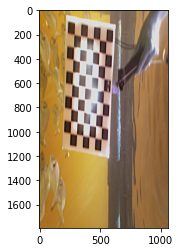

In [19]:
img = cv2.imread('/content/drive/MyDrive/calibration/separation_d/3agosto_ppB_1628005329_d.jpg')
h,  w = img.shape[:2]
newcameramtx_d, roi=cv2.getOptimalNewCameraMatrix(mtx_d,dist_d,(w,h),1,(w,h))
 # undistort
dst = cv2.undistort(img, mtx_d, dist_d, None, newcameramtx_d)
# crop the image
x,y,w,h = roi
dst = dst[y:y+h, x:x+w]
plt.imshow(dst)

# stereo Calibration

In [ ]:
#inspired by https://python.plainenglish.io/the-depth-i-stereo-calibration-and-rectification-24da7b0fb1e0

In [20]:
def save_stereo_coefficients(path, K1, D1, K2, D2, R, T, E, F, R1, R2, P1, P2, Q):
    """ Save the stereo coefficients to given path/file. """
    cv_file = cv2.FileStorage(path, cv2.FILE_STORAGE_WRITE)
    cv_file.write("K1", K1)
    cv_file.write("D1", D1)
    cv_file.write("K2", K2)
    cv_file.write("D2", D2)
    cv_file.write("R", R)
    cv_file.write("T", T)
    cv_file.write("E", E)
    cv_file.write("F", F)
    cv_file.write("R1", R1)
    cv_file.write("R2", R2)
    cv_file.write("P1", P1)
    cv_file.write("P2", P2)
    cv_file.write("Q", Q)
    cv_file.release()

def load_stereo_coefficients(path):
    """ Loads stereo matrix coefficients. """
    # FILE_STORAGE_READ
    cv_file = cv2.FileStorage(path, cv2.FILE_STORAGE_READ)

    # note we also have to specify the type to retrieve other wise we only get a
    # FileNode object back instead of a matrix
    K1 = cv_file.getNode("K1").mat()
    D1 = cv_file.getNode("D1").mat()
    K2 = cv_file.getNode("K2").mat()
    D2 = cv_file.getNode("D2").mat()
    R = cv_file.getNode("R").mat()
    T = cv_file.getNode("T").mat()
    E = cv_file.getNode("E").mat()
    F = cv_file.getNode("F").mat()
    R1 = cv_file.getNode("R1").mat()
    R2 = cv_file.getNode("R2").mat()
    P1 = cv_file.getNode("P1").mat()
    P2 = cv_file.getNode("P2").mat()
    Q = cv_file.getNode("Q").mat()

    cv_file.release()
    return [K1, D1, K2, D2, R, T, E, F, R1, R2, P1, P2, Q]

In [21]:
import numpy as np
import cv2
import glob
import argparse
import sys
#from calibration_store import load_coefficients, save_stereo_coefficients



def load_image_points(left_dir, left_prefix, right_dir, right_prefix, image_format, square_size, width=9, height=6):
    global image_size
    pattern_size = (width, height)  # Chessboard size!
    # prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(8,6,0)
    objp = np.zeros((height * width, 3), np.float32)
    objp[:, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)

    objp = objp * square_size  # Create real world coords. Use your metric.

    # Arrays to store object points and image points from all the images.
    objpoints = []  # 3d point in real world space
    left_imgpoints = []  # 2d points in image plane.
    right_imgpoints = []  # 2d points in image plane.

    # Left directory path correction. Remove the last character if it is '/'
    if left_dir[-1:] == '/':
        left_dir = left_dir[:-1]

    # Right directory path correction. Remove the last character if it is '/'
    if right_dir[-1:] == '/':
        right_dir = right_dir[:-1]

    # Get images for left and right directory. Since we use prefix and formats, both image set can be in the same dir.
    left_images = glob.glob(left_dir + '/' + left_prefix + '*.' + image_format)
    right_images = glob.glob(right_dir + '/' + right_prefix + '*.' + image_format)

    # Images should be perfect pairs. Otherwise all the calibration will be false.
    # Be sure that first cam and second cam images are correctly prefixed and numbers are ordered as pairs.
    # Sort will fix the globs to make sure.
    left_images.sort()
    right_images.sort()

    # Pairs should be same size. Otherwise we have sync problem.
    if len(left_images) != len(right_images):
        print("Numbers of left and right images are not equal. They should be pairs.")
        print("Left images count: ", len(left_images))
        print("Right images count: ", len(right_images))
        sys.exit(-1)

    pair_images = zip(left_images, right_images)  # Pair the images for single loop handling

    # Iterate through the pairs and find chessboard corners. Add them to arrays
    # If openCV can't find the corners in one image, we discard the pair.
    for left_im, right_im in pair_images:
        # Right Object Points
        right = cv2.imread(right_im)
        cv2.imwrite('control.jpg',right)
        gray_right = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)

        # Find the chess board corners
        ret_right, corners_right = cv2.findChessboardCorners(gray_right, pattern_size,
                                                             cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_FILTER_QUADS)

        # Left Object Points
        left = cv2.imread(left_im)
        gray_left = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)

        # Find the chess board corners
        ret_left, corners_left = cv2.findChessboardCorners(gray_left, pattern_size,
                                                           cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_FILTER_QUADS)

        if ret_left and ret_right:  # If both image is okay. Otherwise we explain which pair has a problem and continue
            # Object points
            objpoints.append(objp)
            # Right points
            corners2_right = cv2.cornerSubPix(gray_right, corners_right, (5, 5), (-1, -1), criteria)
            right_imgpoints.append(corners2_right)
            #Andrea: print right image START
            print('here')
            img = cv2.drawChessboardCorners(right, (width, height), corners2_right, ret_right)
            plt.imshow(img)
            plt.show()
            #Andrea: print right image END
            # Left points
            corners2_left = cv2.cornerSubPix(gray_left, corners_left, (5, 5), (-1, -1), criteria)
            left_imgpoints.append(corners2_left)
        else:
            print("Chessboard couldn't be detected. Image pair: ", left_im, " and ", right_im)
            continue

    image_size = gray_right.shape  # If you have no acceptable pair, you may have an error here.
    return [objpoints, left_imgpoints, right_imgpoints]

In [22]:
cd /content/drive/MyDrive/calibration

/content/drive/MyDrive/calibration


In [23]:
objp, leftp, rightp = load_image_points('separation_u', '3agosto', 'separation_d', '3agosto', 'jpg', square_size, width, height)

Output hidden; open in https://colab.research.google.com to view.

In [33]:
K1, D1 = load_coefficients('separation_u/mtx_up.pkl','separation_u/dist_up.pkl')
K2, D2 = load_coefficients('separation_d/mtx_down.pkl','separation_d/dist_down.pkl')

flag = 0
#flag |= cv2.CALIB_FIX_INTRINSIC
#flag |= cv2.CALIB_FIX_ASPECT_RATIO
#flag |= cv2.CALIB_USE_INTRINSIC_GUESS
#ret, K1, D1, K2, D2, R, T, E, F = cv2.stereoCalibrate(objp, leftp, rightp, K1, D1, K2, D2, image_size) 

#(ret, _, _, _, _, R, T, E, F) = cv2.stereoCalibrate(objp, leftp, rightp, K1, D1, K2, D2, image_size, None, None, None, None, cv2.CALIB_FIX_INTRINSIC)
#AR: use the optimal new camera matrix
(ret, _, _, _, _, R, T, E, F) = cv2.stereoCalibrate(objp, leftp, rightp, newcameramtx_u, D1, newcameramtx_d, D2, image_size, None, None, None, None, cv2.CALIB_FIX_INTRINSIC)
print("Stereo calibration rms: ", ret)
#Q disparity to depth map
#save_stereo_coefficients(save_file, K1, D1, K2, D2, R, T, E, F, R1, R2, P1, P2, Q)

Stereo calibration rms:  7.219914342190299


In [30]:
p = np.arange(0.2, 0.3, 0.1)

In [31]:
p

array([0.2])

0.2


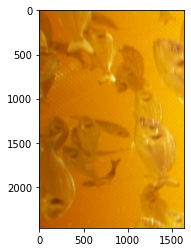

In [36]:
#check best alpha for the rectification
p = np.arange(0.2, 0.3, 0.1)
for i in p:
    print(i)
    #rect_l, rect_r, proj_mat_l, proj_mat_r, Q, roiL, roiR= cv2.stereoRectify(new_mtxL, distL, new_mtxR, distR, imgL_gray.shape[::-1], Rot, Trns, rectify_scale,(0,0))
    #R1, R2, P1, P2, Q, roi_left, roi_right = cv2.stereoRectify(K1, D1, K2, D2, image_size, R, T, flags=cv2.CALIB_ZERO_DISPARITY, alpha=i)
    R1, R2, P1, P2, Q, roi_left, roi_right = cv2.stereoRectify(newcameramtx_u, D1, newcameramtx_d, D2, image_size, R, T, flags=cv2.CALIB_ZERO_DISPARITY, alpha=i)
    #test Image
    left_image = cv2.imread('/content/drive/MyDrive/calibration/test/1628007058photo_u.jpg')
    right_image = cv2.imread('/content/drive/MyDrive/calibration/test/1628007058photo_d.jpg')
    height, width = right_image.shape[:2]

    #plt.imshow(right_image)
    #plt.show()
    leftMapX, leftMapY = cv2.initUndistortRectifyMap(newcameramtx_u, D1, R1, P1, (width, height), cv2.CV_32FC1)
    left_rectified = cv2.remap(left_image, leftMapX, leftMapY, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
    rightMapX, rightMapY = cv2.initUndistortRectifyMap(newcameramtx_d, D2, R2, P2, (width, height), cv2.CV_32FC1)
    right_rectified = cv2.remap(right_image, rightMapX, rightMapY, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)

    plt.imshow(left_rectified)
    plt.show()
    #plt.imshow(right_rectified)
    #plt.show()

In [ ]:
#K1, D1, K2, D2, R, T, E, F, R1, R2, P1, P2, Q = load_stereo_coefficients('Stereo.yml')
p

array([0.])

In [ ]:
#leftMapX, leftMapY = cv2.initUndistortRectifyMap(K1, D1, None, newcameramtx_u, (width, height), cv2.CV_32FC1)
#left_rectified = cv2.remap(left_image, leftMapX, leftMapY, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
#rightMapX, rightMapY = cv2.initUndistortRectifyMap(K2, D2, None, newcameramtx_d, (width, height), cv2.CV_32FC1)
#right_rectified = cv2.remap(right_image, rightMapX, rightMapY, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)

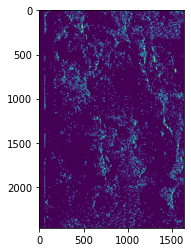

In [37]:
#disparity map

# Setting parameters for StereoSGBM algorithm

minDisparity = 0;
numDisparities = 64;
blockSize = 8;
disp12MaxDiff = 1;
uniquenessRatio = 10;
speckleWindowSize = 10;
speckleRange = 8;

stereo = cv2.StereoSGBM_create(minDisparity = minDisparity,
        numDisparities = numDisparities,
        blockSize = blockSize,
        disp12MaxDiff = disp12MaxDiff,
        uniquenessRatio = uniquenessRatio,
        speckleWindowSize = speckleWindowSize,
        speckleRange = speckleRange
    )
# Calculating disparith using the StereoSGBM algorithm
disp = stereo.compute(left_rectified, right_rectified).astype(np.float32)
disp = cv2.normalize(disp,0,255,cv2.NORM_MINMAX)

# Displaying the disparity map

plt.imshow(disp)


In [38]:
#another test
def depth_map(imgL, imgR):
    """ Depth map calculation. Works with SGBM and WLS. Need rectified images, returns depth map ( left to right disparity ) """
    # SGBM Parameters -----------------
    window_size = 3  # wsize default 3; 5; 7 for SGBM reduced size image; 15 for SGBM full size image (1300px and above); 5 Works nicely

    left_matcher = cv2.StereoSGBM_create(
        minDisparity=1, # Andrea changed from -1
        numDisparities=5*16,  # max_disp has to be dividable by 16 f. E. HH 192, 256
        blockSize=window_size,
        P1=8 * 3 * window_size,
        # wsize default 3; 5; 7 for SGBM reduced size image; 15 for SGBM full size image (1300px and above); 5 Works nicely
        P2=32 * 3 * window_size,
        disp12MaxDiff=12,
        uniquenessRatio=10,
        speckleWindowSize=50,
        speckleRange=32,
        preFilterCap=63,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )
    right_matcher = cv2.ximgproc.createRightMatcher(left_matcher)
    # FILTER Parameters
    lmbda = 80000
    sigma = 1.3
    visual_multiplier = 6

    wls_filter = cv2.ximgproc.createDisparityWLSFilter(matcher_left=left_matcher)
    wls_filter.setLambda(lmbda)

    wls_filter.setSigmaColor(sigma)
    displ = left_matcher.compute(imgL, imgR)  # .astype(np.float32)/16
    dispr = right_matcher.compute(imgR, imgL)  # .astype(np.float32)/16
    displ = np.int16(displ)
    dispr = np.int16(dispr)
    filteredImg = wls_filter.filter(displ, imgL, None, dispr)  # important to put "imgL" here!!!

    filteredImg = cv2.normalize(src=filteredImg, dst=filteredImg, beta=0, alpha=255, norm_type=cv2.NORM_MINMAX);
    filteredImg = np.uint8(filteredImg)

    return filteredImg

In [39]:
gray_left = cv2.cvtColor(left_rectified, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(right_rectified, cv2.COLOR_BGR2GRAY)
disparity_image = depth_map(gray_left, gray_right)  # Get the disparity map

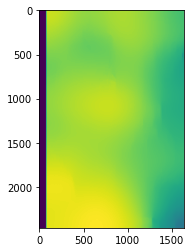

In [40]:
plt.imshow(disparity_image)
plt.show()

In [ ]:
h ,w = disparity_image.shape
h ,w

(1640, 2464)

In [ ]:
cut_disparity = disparity_image[:,100:w-100]


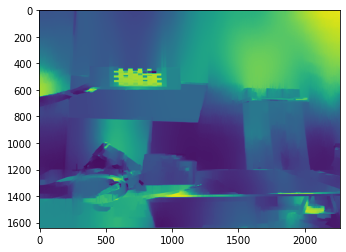

In [ ]:
plt.imshow(cut_disparity)
plt.show()

In [ ]:
cut_disparity
hh , ww = cut_disparity.shape
#cut_disparity[100,ww-100:ww]=0

In [ ]:
print(cut_disparity[100,100])
print(cut_disparity[100,ww-100]) 

76
234


In [ ]:
f = 3.04
B = 80
Z = B*f / cut_disparity

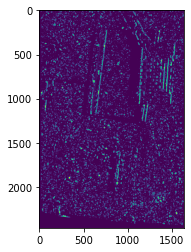

In [ ]:
#other method
gray_left = cv2.cvtColor(left_rectified, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(right_rectified, cv2.COLOR_BGR2GRAY)
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)
disparity = stereo.compute(gray_left,gray_right)
plt.imshow(disparity)
plt.show()